# Phase 2 Experiments — 17 Patients

Comparing phase 2 improvements against v8_mixed baseline (Dice = 0.781).

| # | Experiment | Description | Status |
|---|---|---|---|
| Baseline | v8_mixed | v7_mixed checkpoint, standard inference | Done — 0.781 |
| Exp B | v8_filled | v8_mixed predictions + fill_holes + component filter | Done — 0.778 |
| Exp A | v8_clipped | v7_mixed checkpoint + 95th-pct input clipping | Done — 0.784 |
| v9 | v9_mixed | Segmentation-restricted CE loss (background excluded) | Done — 0.753 |
| v10 | v10_boundary | Standard CE + Dice + boundary-aware loss | Done — 0.753 |
| v11 | v11_cldice | Standard CE + Dice + clDice topology loss | Done — 0.777 |
| v12a | v12_tversky | v7_mixed recipe + TverskyLoss(α=0.3, β=0.7) | Inference done |
| v12b | v12_photometric | v7_mixed recipe + photometric aug on fake PD | Inference done |

In [1]:
import os, re, glob
import numpy as np
import nibabel as nib
import SimpleITK as sitk
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────
BASE = "/Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2"
RES  = f"{BASE}/results"
RES_FINAL = f"{BASE}/results/final_results"

GT_DIR_D1  = "/Users/anshikabajpai/Desktop/AImed-lab/SEGMENTATIONS/PD-segmentations-final"
GT_DIR_NEW = "/Users/anshikabajpai/Downloads/final-segmentations"   # fixed path

# Prediction dirs — missing dirs are skipped automatically
PRED_DIRS = {
    "v8_mixed"        : f"{RES_FINAL}/real_pd_predictions_v8_mixed",       # baseline
    "v8_filled"       : f"{RES}/real_pd_predictions_v8_filled",             # Exp B
    "v8_clipped"      : f"{RES_FINAL}/real_pd_predictions_v8_clipped",      # Exp A
    "v9_mixed"        : f"{RES_FINAL}/real_pd_predictions_v9_mixed",        # restr. CE
    "v10_boundary"    : f"{RES_FINAL}/real_pd_predictions_v10_boundary",    # boundary loss
    "v11_cldice"      : f"{RES_FINAL}/real_pd_predictions_v11_cldice",      # clDice loss
    "v12_tversky"     : f"{RES_FINAL}/real_pd_predictions_v12_tversky",     # Tversky loss
    "v12_photometric" : f"{RES_FINAL}/real_pd_predictions_v12_photometric", # photometric aug
}

D1_PATIENTS = [
    "AC0D5A4D78B628", "AC0D7BF72F7712", "AC0D3459553205", "AC14D3737C0482",
    "AC19E7C19827FF", "AC149BC218E75C", "AC111633B463BB", "AC13300201B926",
    "AC12026D14291F", "AC13637DA25399",
]
NEW_PATIENTS = [
    "AC000550763509", "AC005135D3495B", "AC04433E37DB66", "AC056ADCE8BE28",
    "AC07607B9E5295", "AC0D1A9818A6FC", "AC0F11041F5180",
]
ALL_PATIENTS = D1_PATIENTS + NEW_PATIENTS

# Show which experiments are ready
for name, path in PRED_DIRS.items():
    n = len(glob.glob(os.path.join(path, '*.nii.gz'))) if os.path.isdir(path) else 0
    status = f"{n} files" if n > 0 else "NOT READY (pending SCP)"
    print(f"  {name:<18}: {status}")
print(f"\nTotal patients: {len(ALL_PATIENTS)}  (D1={len(D1_PATIENTS)}, new={len(NEW_PATIENTS)})")

In [3]:
# ── Helpers (same as v8 notebook) ─────────────────────────────────────────
def get_pid(fname):
    m = re.match(r"(AC[A-F0-9]+)", os.path.basename(fname), re.IGNORECASE)
    return m.group(1) if m else None

def patients_in_dir(directory, pattern="*.nii.gz"):
    if not os.path.isdir(directory):
        return {}
    files = glob.glob(os.path.join(directory, pattern))
    return {get_pid(f): f for f in files if get_pid(f)}

def load_nrrd_binary(path):
    img = sitk.ReadImage(path)
    arr = sitk.GetArrayFromImage(img)
    if arr.ndim == 4:
        arr = (arr.max(axis=0) > 0).astype(np.uint8)
        out = sitk.GetImageFromArray(arr)
        try:
            comp = sitk.VectorIndexSelectionCast(img, 0)
            out.CopyInformation(comp)
        except Exception:
            out.SetSpacing(img.GetSpacing()[:3]); out.SetOrigin(img.GetOrigin()[:3])
            out.SetDirection(img.GetDirection()[:9])
    else:
        arr = (arr > 0).astype(np.uint8)
        out = sitk.GetImageFromArray(arr)
        out.CopyInformation(img)
    try: out = sitk.DICOMOrient(out, "RAS")
    except Exception: pass
    sp  = out.GetSpacing()
    arr = sitk.GetArrayFromImage(out).astype(np.float32).transpose(2, 1, 0)
    fa, fs = float(sp[1]) / min(sp[1], sp[2]), float(sp[2]) / min(sp[1], sp[2])
    if abs(fa - 1.0) > 0.02 or abs(fs - 1.0) > 0.02:
        arr = zoom(arr, (1.0, fa, fs), order=0)
    _, n_A, n_S = arr.shape
    if n_A != 384 or n_S != 384:
        arr = zoom(arr, (1.0, 384/n_A, 384/n_S), order=0)
    return (arr > 0.5).astype(bool)

def load_vol(path): return np.asarray(nib.load(path).get_fdata())
def merge_meniscus(pred): return (pred > 0).astype(bool)
def dice_score(pred_bin, gt_bin):
    inter = (pred_bin & gt_bin).sum(); denom = pred_bin.sum() + gt_bin.sum()
    return float(2 * inter / denom) if denom > 0 else 1.0

In [4]:
# ── Find GT masks ──────────────────────────────────────────────────────────
gt_masks = {}
for pid in ALL_PATIENTS:
    hits = (glob.glob(os.path.join(GT_DIR_D1,  f"{pid}*.seg.nrrd")) or
            glob.glob(os.path.join(GT_DIR_NEW, f"{pid}*.seg.nrrd")))
    if hits: gt_masks[pid] = hits[0]
    else: print(f"WARNING: No GT mask for {pid}")
print(f"GT masks found: {len(gt_masks)}/17")

# Load prediction dicts (empty dict if dir not ready)
preds_map = {name: patients_in_dir(path) for name, path in PRED_DIRS.items()}
for name, pmap in preds_map.items():
    print(f"  {name:<14}: {len(pmap)} predictions loaded")

GT masks found: 17/17
  v8_mixed      : 17 predictions loaded
  v8_filled     : 17 predictions loaded
  v8_clipped    : 17 predictions loaded
  v9_mixed      : 17 predictions loaded
  v10_boundary  : 17 predictions loaded
  v11_cldice    : 17 predictions loaded


In [5]:
# ── Compute Dice ───────────────────────────────────────────────────────────
results = []
run_names = list(PRED_DIRS.keys())

for pid in ALL_PATIENTS:
    if pid not in gt_masks:
        print(f"SKIP {pid} — no GT mask"); continue

    gt_bin = load_nrrd_binary(gt_masks[pid])
    row = {"patient": pid, "cohort": "D1" if pid in D1_PATIENTS else "new"}

    for name, pmap in preds_map.items():
        key = f"dice_{name}"
        if pid in pmap:
            pred = load_vol(pmap[pid])
            row[key] = dice_score(merge_meniscus(pred), gt_bin)
        else:
            row[key] = float("nan")

    results.append(row)
    scores = "  ".join(
        f"{n}={row[f'dice_{n}']:.3f}" if not np.isnan(row[f'dice_{n}']) else f"{n}=---"
        for n in run_names
    )
    print(f"{pid} ({row['cohort']})  {scores}")

# ── Means ──────────────────────────────────────────────────────────────────
means_all, means_d1, means_new = {}, {}, {}
for rn in run_names:
    key = f"dice_{rn}"
    all_v = [r[key] for r in results if not np.isnan(r.get(key, float("nan")))]
    d1_v  = [r[key] for r in results if r["cohort"]=="D1"  and not np.isnan(r.get(key, float("nan")))]
    new_v = [r[key] for r in results if r["cohort"]=="new" and not np.isnan(r.get(key, float("nan")))]
    means_all[rn] = np.mean(all_v) if all_v else float("nan")
    means_d1[rn]  = np.mean(d1_v)  if d1_v  else float("nan")
    means_new[rn] = np.mean(new_v) if new_v  else float("nan")

print("\n" + "="*70)
print("PHASE 2 SUMMARY — 17 patients")
print("="*70)
print(f"{'Experiment':<16} {'All 17':>8} {'D1 (10)':>10} {'New (7)':>10} {'vs baseline':>12}")
print("-"*58)
baseline_all = means_all.get("v8_mixed", float("nan"))
for rn in run_names:
    a = means_all[rn]; d = means_d1[rn]; n = means_new[rn]
    delta = f"+{a - baseline_all:+.4f}" if not np.isnan(a) and rn != "v8_mixed" else "(baseline)"
    a_str = f"{a:.4f}" if not np.isnan(a) else "pending"
    d_str = f"{d:.4f}" if not np.isnan(d) else "pending"
    n_str = f"{n:.4f}" if not np.isnan(n) else "pending"
    print(f"{rn:<16} {a_str:>8} {d_str:>10} {n_str:>10} {delta:>12}")

AC0D5A4D78B628 (D1)  v8_mixed=0.709  v8_filled=0.703  v8_clipped=0.713  v9_mixed=0.692  v10_boundary=0.698  v11_cldice=0.730
AC0D7BF72F7712 (D1)  v8_mixed=0.777  v8_filled=0.767  v8_clipped=0.781  v9_mixed=0.721  v10_boundary=0.735  v11_cldice=0.779
AC0D3459553205 (D1)  v8_mixed=0.725  v8_filled=0.723  v8_clipped=0.737  v9_mixed=0.733  v10_boundary=0.705  v11_cldice=0.756
AC14D3737C0482 (D1)  v8_mixed=0.791  v8_filled=0.771  v8_clipped=0.786  v9_mixed=0.745  v10_boundary=0.740  v11_cldice=0.785
AC19E7C19827FF (D1)  v8_mixed=0.802  v8_filled=0.798  v8_clipped=0.806  v9_mixed=0.788  v10_boundary=0.809  v11_cldice=0.779
AC149BC218E75C (D1)  v8_mixed=0.801  v8_filled=0.791  v8_clipped=0.803  v9_mixed=0.788  v10_boundary=0.777  v11_cldice=0.797
AC111633B463BB (D1)  v8_mixed=0.809  v8_filled=0.805  v8_clipped=0.811  v9_mixed=0.771  v10_boundary=0.787  v11_cldice=0.822
AC13300201B926 (D1)  v8_mixed=0.763  v8_filled=0.755  v8_clipped=0.764  v9_mixed=0.702  v10_boundary=0.733  v11_cldice=0.770


In [ ]:
# ── Bar chart ──────────────────────────────────────────────────────────────
COLORS = {
    "v8_mixed"        : "#888888",
    "v8_filled"       : "#4C9BE8",
    "v8_clipped"      : "#F4A261",
    "v9_mixed"        : "#2A9D8F",
    "v10_boundary"    : "#E76F51",
    "v11_cldice"      : "#8338EC",
    "v12_tversky"     : "#C1121F",
    "v12_photometric" : "#588157",
}
LABELS = {
    "v8_mixed"        : "v8_mixed\n(baseline)",
    "v8_filled"       : "Exp B\nfill_holes",
    "v8_clipped"      : "Exp A\nclip 95pct",
    "v9_mixed"        : "v9_mixed\nrestr. CE",
    "v10_boundary"    : "v10\nboundary loss",
    "v11_cldice"      : "v11\nclDice",
    "v12_tversky"     : "v12a\nTversky",
    "v12_photometric" : "v12b\nphotometric",
}

ready = [rn for rn in run_names if not np.isnan(means_all[rn])]
vals  = [means_all[rn] for rn in ready]
cols  = [COLORS[rn] for rn in ready]
labs  = [LABELS[rn] for rn in ready]

fig, ax = plt.subplots(figsize=(max(5, len(ready)*2), 5))
bars = ax.bar(labs, vals, color=cols, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.3f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.axhline(baseline_all, color="#888888", linestyle="--", linewidth=1, label=f"baseline {baseline_all:.3f}")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Mean Dice (meniscus)", fontsize=12)
ax.set_title("Phase 2 Experiments — 17 Patients", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
os.makedirs(f"{BASE}/figures/v8", exist_ok=True)
plt.savefig(f"{BASE}/figures/v8/dice_phase2_experiments.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> figures/v8/dice_phase2_experiments.png")

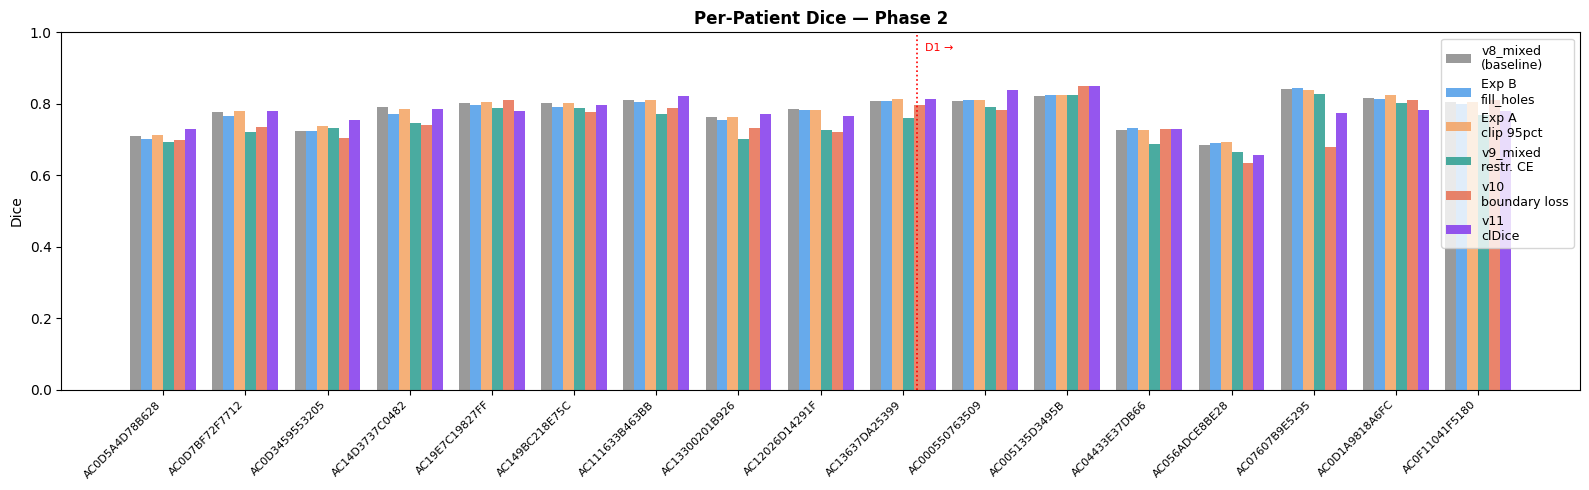

Saved -> figures/v8/dice_phase2_perpatient.png


In [7]:
# ── Per-patient comparison (ready experiments only) ─────────────────────────
ready = [rn for rn in run_names if not np.isnan(means_all[rn])]
pids  = [r["patient"] for r in results]
x     = np.arange(len(pids))
width = 0.8 / len(ready)

fig, ax = plt.subplots(figsize=(16, 5))
for i, rn in enumerate(ready):
    vals = [r[f"dice_{rn}"] for r in results]
    ax.bar(x + i * width, vals, width, label=LABELS[rn], color=COLORS[rn], alpha=0.85)

ax.set_xticks(x + width * (len(ready)-1)/2)
ax.set_xticklabels([p[:14] for p in pids], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Dice"); ax.set_ylim(0, 1.0)
ax.set_title("Per-Patient Dice — Phase 2", fontweight="bold")
ax.legend(fontsize=9)
# Mark D1 / new boundary
ax.axvline(len(D1_PATIENTS) - 0.5, color="red", linestyle=":", linewidth=1.2, label="D1 | new")
ax.text(len(D1_PATIENTS) - 0.4, 0.97, "D1 →", color="red", fontsize=8, va="top")
plt.tight_layout()
plt.savefig(f"{BASE}/figures/v8/dice_phase2_perpatient.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> figures/v8/dice_phase2_perpatient.png")